In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
ruta = "../out/corriente_CR39.out"

num = []
corriente = []
error = []

leyendo = False

with open(ruta, "r") as f:
    for linea in f:
        if "#  num" in linea and "area" in linea and "proton" in linea:
            leyendo = True
            continue

        if leyendo:
            if "#   sum" in linea:
                break

            datos = linea.split()

            if len(datos) >= 4:
                try:
                    num.append(int(datos[0]))
                    corriente.append(float(datos[2]))
                    error.append(float(datos[3]))
                except ValueError:
                    pass

num = np.array(num)
corriente = np.array(corriente)
error = np.array(error)

columnas = {
    "Columna 1": corriente[0:9],
    "Columna 2": corriente[9:16],
    "Columna 3": corriente[16:21],
    "Columna 4": corriente[21:24],
}

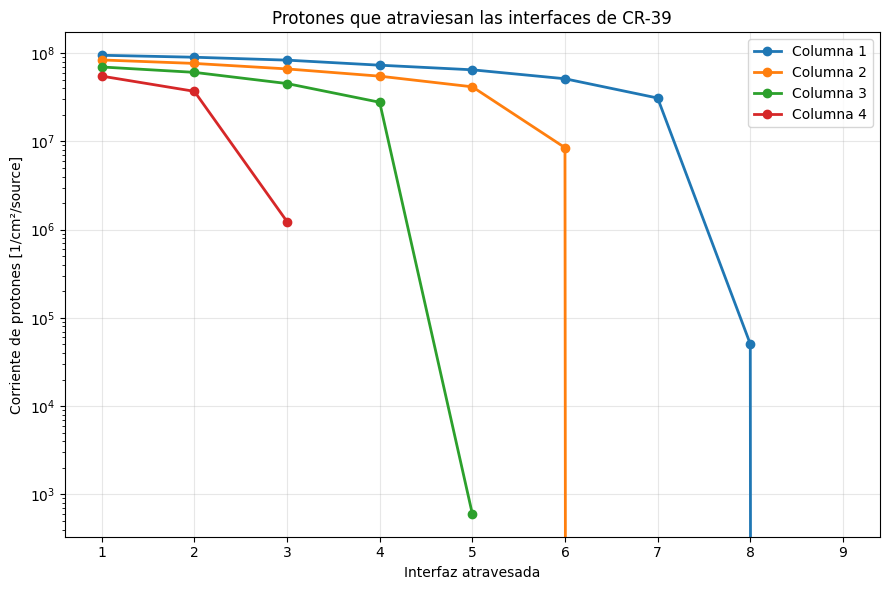

In [3]:
plt.figure(figsize=(9, 6))

for nombre, valores in columnas.items():
    interfaces = np.arange(1, len(valores) + 1)
    plt.plot(interfaces, valores, marker="o", linewidth=2, label=nombre)

plt.xlabel("Interfaz atravesada")
plt.ylabel("Corriente de protones [1/cm²/source]")
plt.title("Protones que atraviesan las interfaces de CR-39")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

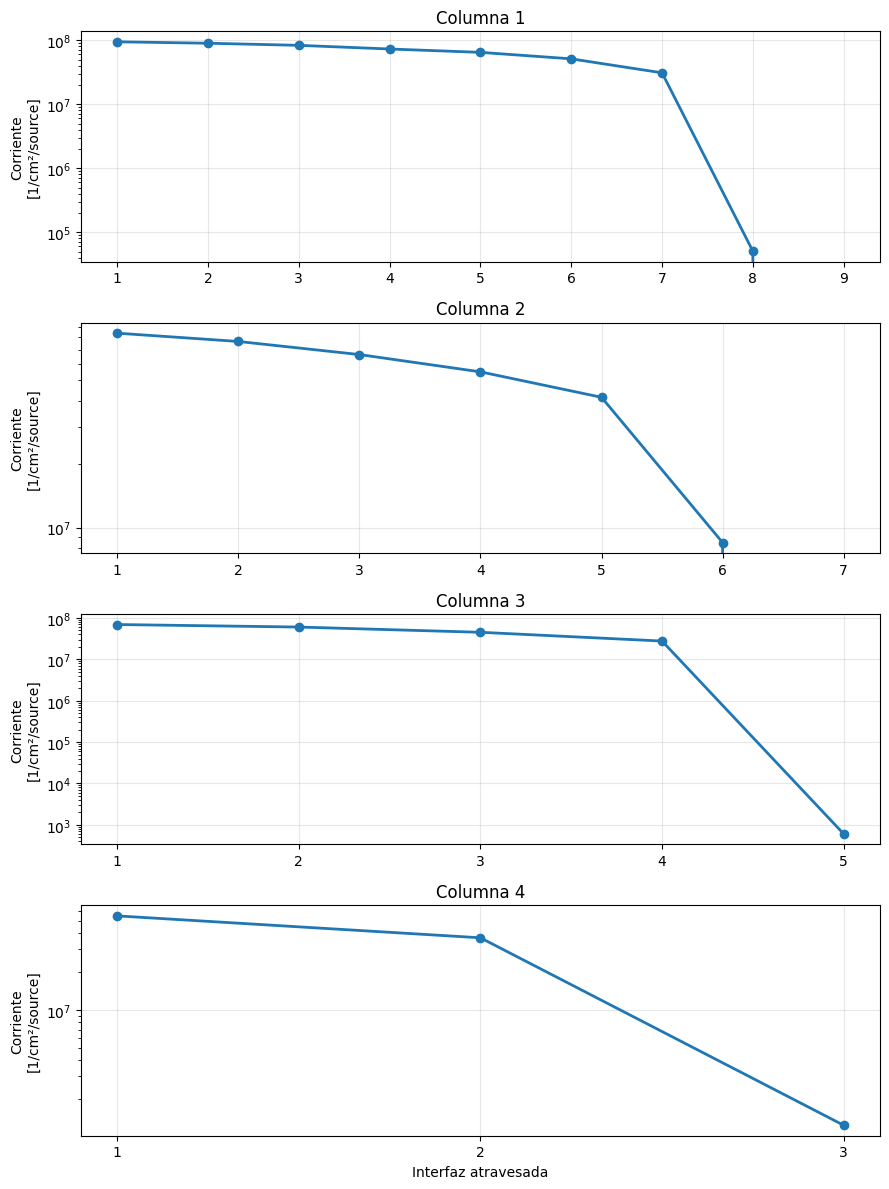

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(9, 12))

for ax, (nombre, valores) in zip(axes, columnas.items()):
    interfaces = np.arange(1, len(valores) + 1)

    ax.plot(interfaces, valores, marker="o", linewidth=2)
    ax.set_yscale("log")
    ax.set_xticks(interfaces)
    ax.set_ylabel("Corriente\n[1/cm²/source]")
    ax.set_title(nombre)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Interfaz atravesada")

plt.tight_layout()
plt.show()

acá hay algo interesante: en la columna 1 llegan prácticamente hasta la interfaz 8, en la 2 hasta la 6, en la 3 casi se extinguen en la 5 y en la 4 todavía hay protones en la tercera interfaz.